# Evaluate

This notebook evaluates the quality of the online alignments in a given experiment directory.

In [1]:
%matplotlib inline

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import pandas as pd
import pickle
import re
import import_ipynb
import system_utils
import eval_tools

## Calculate Alignment Errors

First we calculate the alignment errors of a given system on all evaluated measures.

In [1]:
systems = ['DTW', 'OLTW', 'OLTW-Ours', 'OLTW-Global', 'SOA', 'SOA-Mono', 'SOA-NN']
lags = [0, 100, 200, 300, 400, 500]
scenarios_dir = 'scenarios_test'

### Evaluate Alignment

In [ ]:
evaluating_match = False
EXP_DIR = f"experiments{'_match' if evaluating_match else ''}"
EVAL_DIR = f"eval{'_match' if evaluating_match else ''}"
for system_idx in range(len(systems)):
    exp_dir = f'{EXP_DIR}/{systems[system_idx]}'
    eval_dir = f'{EVAL_DIR}/{exp_dir[18:] if evaluating_match else exp_dir[12:]}'
    eval_tools.eval_alignment_batch(exp_dir, scenarios_dir, eval_dir)

## Plot Error vs Tolerance

We can visualize the results by plotting the error rate across a range of error tolerances.

In [7]:

def plotErrorVsTolerance(eval_dirs, maxTol, savefile = None, style='bar', tols = None, bar_tols=None):
    '''
    Plots the error rate across a range of error tolerances.

    Inputs
    eval_dir: the eval directories to plot
    maxTol: maximum error tolerance to consider (in milliseconds)
    savefile: if specified, will save the figure to the given filepath
    style: 'bar' or 'line'
    tols: list of error tolerances to evaluate at
    bar_tols: list of error tolerances to plot if using 'bar'
    '''

    errRates_list = []
    num_systems = len(eval_dirs)
    for i, eval_dir in enumerate(eval_dirs):

        # load
        with open(f'{eval_dir}/errs.pkl', 'rb') as f:
            d = pickle.load(f)

        # flattened list
        errs = []
        for scenario_id in d:
            errs = np.append(errs, d[scenario_id])

        # calculate error rates
        if tols is None:
            tols = np.arange(maxTol+1)
        if bar_tols is None:
            bar_tols = tols
        errRates = np.zeros(len(tols))
        for j in range(len(tols)):
            filtered_errs = [e for e in errs if e is not None]
            try:
                errRates[j] = np.mean(np.abs(filtered_errs) > tols[j]/1000)
            except Exception as e:
                print(f"Error: {filtered_errs} | Exception: {e}")

        errRates_list.append(errRates)

        if style == 'line':
            plt.plot(tols, errRates * 100.0)
        elif style == 'bar':
            # Adaptively set bar_width based on the number of systems so that bars are visually balanced
            bar_width = 0.8 / num_systems if num_systems > 0 else 0.1
            errs = [errRates[tol] * 100.0 for tol in range(len(bar_tols))]
            pos = np.arange(len(errs)) + i * bar_width
            plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir))
            plt.xticks([r + bar_width*num_systems/2 - bar_width/2 for r in range(len(bar_tols))], map(str, bar_tols))

    plt.ylabel('Error Rate (%)')
    plt.xlabel('Error Tolerance (ms)')
    plt.legend([os.path.basename(eval_dir) for eval_dir in eval_dirs])
    plt.grid(linestyle='--')
    plt.show()
    if savefile:
        plt.savefig(savefile)
    return errRates_list, tols

Plot the error rate vs error tolerance curve for one system of interest:

eval_test/SOA-NN


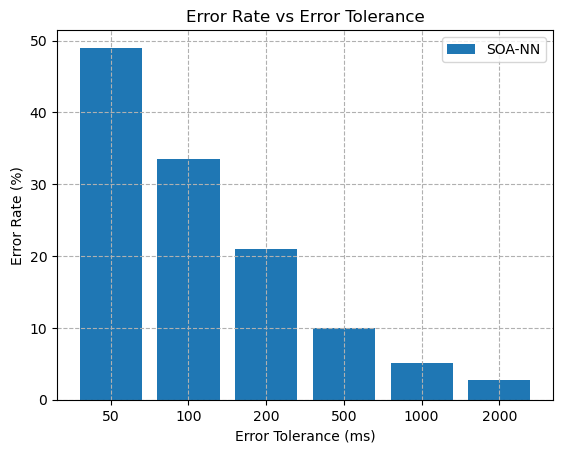

In [6]:
maxTol = 5000 # in milliseconds
tols = [50, 100,200,500, 1000, 2000]
eval_dir = f'eval_test/{systems[-1]}'
print(eval_dir)
errRates_list, tols = plotErrorVsTolerance([eval_dir], maxTol, tols = tols, savefile=False)

Overlay multiple error curves for comparison:

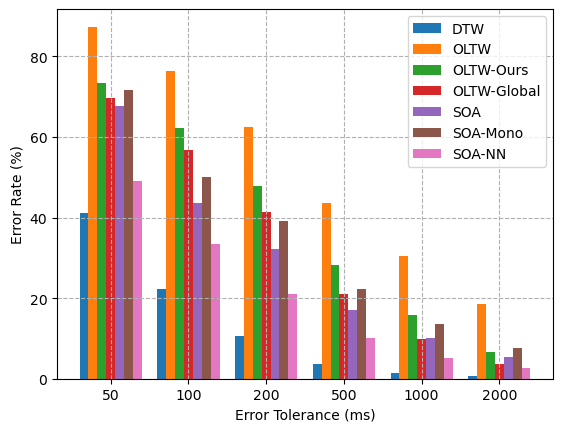

In [8]:
systems_to_compare = systems
eval_dirs = [f'eval_test/{s}' for s in systems_to_compare]
errRates_list, tols = plotErrorVsTolerance(eval_dirs, maxTol = 2000, tols = tols)

In [ ]:
# Create a DataFrame where each column is a system and each row is a tolerance
df = pd.DataFrame(
    {system: err for system, err in zip(systems_to_compare, errRates_list)},
    index=tols
)
df.index.name = "Tolerance (ms)"
df.columns.name = "System"
display(df)